Found 7249 images belonging to 12 classes.
Found 2409 images belonging to 12 classes.
Found 114 images belonging to 12 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ rescaling (Rescaling)       │ (None, 300, 300, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ inception_v3 (Functional)   │ (None, 8, 8, 2048)    │ 21,802,784 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ output-layer (Dense)        │ (None, 12)            │     24,588 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 21,827,372 (83.26 MB)

 Trainable params: 24,588 (96.05 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

c:\Users\Ramiro\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
454/454 ━━━━━━━━━━━━━━━━━━━━ 0s 827ms/step - accuracy: 0.5946 - loss: 0.2517

c:\Users\Ramiro\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


454/454 ━━━━━━━━━━━━━━━━━━━━ 431s 932ms/step - accuracy: 0.5950 - loss: 0.2514 - val_accuracy: 0.3801 - val_loss: 0.3822 - learning_rate: 0.0010
Epoch 2/15
454/454 ━━━━━━━━━━━━━━━━━━━━ 417s 918ms/step - accuracy: 0.9123 - loss: 0.0430 - val_accuracy: 0.4274 - val_loss: 0.3831 - learning_rate: 0.0010
Epoch 3/15
454/454 ━━━━━━━━━━━━━━━━━━━━ 408s 898ms/step - accuracy: 0.9271 - loss: 0.0324 - val_accuracy: 0.4257 - val_loss: 0.3961 - learning_rate: 0.0010
Epoch 4/15
454/454 ━━━━━━━━━━━━━━━━━━━━ 412s 906ms/step - accuracy: 0.9518 - loss: 0.0207 - val_accuracy: 0.4426 - val_loss: 0.4133 - learning_rate: 0.0010
Epoch 5/15
454/454 ━━━━━━━━━━━━━━━━━━━━ 397s 874ms/step - accuracy: 0.9504 - loss: 0.0210 - val_accuracy: 0.4105 - val_loss: 0.4166 - learning_rate: 0.0010
Epoch 6/15
454/454 ━━━━━━━━━━━━━━━━━━━━ 393s 865ms/step - accuracy: 0.9551 - loss: 0.0176 - val_accuracy: 0.4493 - val_loss: 0.3782 - learning_rate: 0.0010
Epoch 7/15
454/454 ━━━━━━━━━━━━━━━━━━━━ 396s 872ms/step - accuracy: 0.9635 

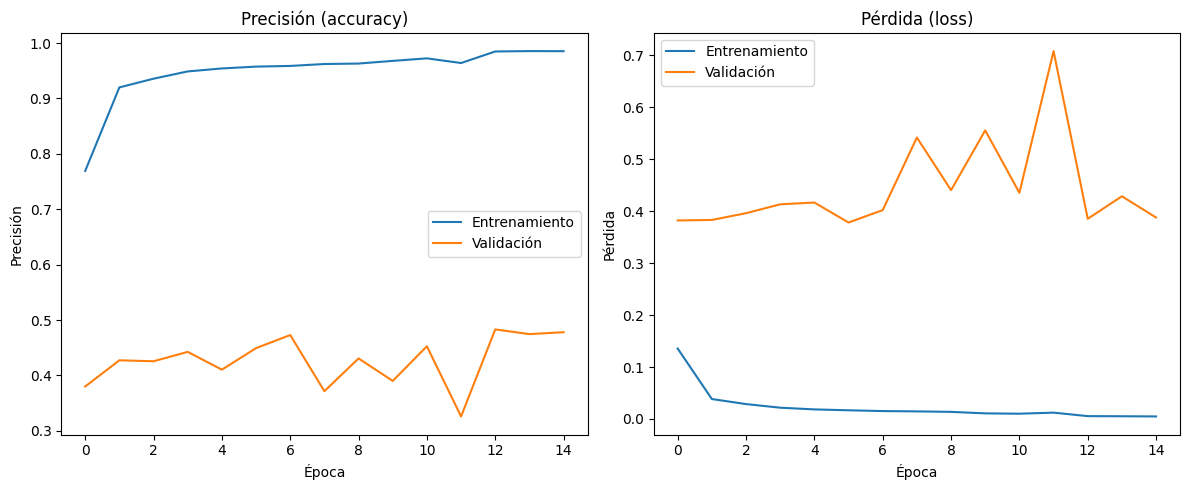

Evaluamos el modelo (Sin fine tunning)


TypeError: evaluarModelo() missing 2 required positional arguments: 'validation' and 'test'

In [ ]:
import os
import keras
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import DirectoryIterator, ImageDataGenerator
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# ------------------

def curvasEntrenamiento(history):
    # Graficar accuracy
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Validación')
    plt.title('Precisión (accuracy)')
    plt.xlabel('Época')
    plt.ylabel('Precisión')
    plt.legend()

    # Graficar loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Entrenamiento')
    plt.plot(history.history['val_loss'], label='Validación')
    plt.title('Pérdida (loss)')
    plt.xlabel('Época')
    plt.ylabel('Pérdida')
    plt.legend()

    plt.tight_layout()
    plt.show()

def evaluarModelo(model, train, validation, test):
    # Evaluamos el modelo
    train_loss, train_accuracy = model.evaluate(train)
    validation_loss, validation_accuracy = model.evaluate(validation)
    test_loss, test_accuracy = model.evaluate(test)

    # Graficar el loss y accuracy de train, validacion y test
    # en un histograma, donde cada columna tiene un color diferente
    labels = ['Train', 'Validation', 'Test']
    losses = [train_loss, validation_loss, test_loss]
    accuracies = [train_accuracy, validation_accuracy, test_accuracy]
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.bar(labels, losses, color=['blue', 'orange', 'green'])
    plt.title('Pérdida (loss)')
    plt.xlabel('Conjunto de datos')
    plt.ylabel('Pérdida')
    plt.subplot(1, 2, 2)
    plt.bar(labels, accuracies, color=['blue', 'orange', 'green'])
    plt.title('Precisión (accuracy)')
    plt.xlabel('Conjunto de datos')
    plt.ylabel('Precisión')
    plt.tight_layout()
    plt.show()

# ------------------

# Ruta al dataset
pathDataset = "./dataset"

IMAGE_SIZE = 300
BATCH_SIZE = 16

# Obtengo los datos, a los datos de entrenamiento se le aplica data aumentation
numClasses = len(os.listdir(pathDataset + "/train"))
pathDataset = "./dataset"

trainValDataMod = ImageDataGenerator(
    validation_split=0.25,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

testDataMod = ImageDataGenerator()

# Datos de entrenamiento
train = trainValDataMod.flow_from_directory(
    directory=pathDataset + "/train",
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

# Datos de validación
validation = trainValDataMod.flow_from_directory(
    directory=pathDataset + "/train",
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

# Datos de prueba
test = testDataMod.flow_from_directory(
    directory=pathDataset + "/test",
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
)

# ------------------------------------

    
base_model = keras.applications.InceptionV3(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freezamos el modelo (la base)
base_model.trainable = False

# Creamos nuevo modelo en top
inputs = keras.layers.Input(shape=(IMAGE_SIZE,IMAGE_SIZE,3))

# Escalamos imagenes para que esten entre -1 y 1
scale_layer = keras.layers.Rescaling(scale=1/ 127.5,  offset=-1)
x = scale_layer(inputs)

model = keras.Sequential([
    inputs,
    scale_layer,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(numClasses, activation='softmax', name="output-layer") # esta capa clasifica las clases
])

model.summary(show_trainable=True)

# ------------------------------------

EPOCHS = 15

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalFocalCrossentropy(),#'categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
bestModel = "./bestModel.keras"
os.makedirs(os.path.dirname(bestModel), exist_ok=True)
callbacks = [
    ModelCheckpoint(bestModel, mode="max", save_best_only=True, monitor="val_accuracy"),
    ReduceLROnPlateau(monitor="val_accuracy", mode="max", patience=5, factor=0.1, verbose=1, min_lr=1e-6),
    EarlyStopping(monitor="val_accuracy", mode="max", patience=10, restore_best_weights=True)
]

# Entreno el modelo
history = model.fit(train,epochs=EPOCHS, 
                    validation_steps=int(0.25 * len(validation)), 
                    validation_data=validation, callbacks=callbacks)


print("Curvas entrenamientos (Sin fine tunning)")
curvasEntrenamiento(history)

print("Evaluamos el modelo (Sin fine tunning)")
evaluarModelo(model, test, validation, test)

# ------------------------------------

# Realizamos el fine tunning
base_model_layers = len(base_model.layers)

print(f"EL modelo posee {base_model_layers} capas.")

# Fine tunning en las ultimas 100 capas
fine_tunning_layers = 100
fine_tune_at = base_model_layers - fine_tunning_layers
print("Capas no entrenables:", fine_tune_at)
print("Capas entrenables:", base_model_layers - fine_tune_at)

# Descongelamos las capas que vamos a entrenar
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

# Recompilamos el modelo con un learning rate más bajo
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.CategoricalFocalCrossentropy(),
    metrics=['accuracy']
)

FT_EPOCHS = 10

TOTAL_EPOCHS = EPOCHS + FT_EPOCHS

fine_tunning_history = model.fit(
    train, validation_data=validation,
    epochs=TOTAL_EPOCHS, callbacks=callbacks,
    initial_epoch=len(history.epoch)
)

print("Curvas entrenamientos (Con fine tunning)")
curvasEntrenamiento(fine_tunning_history, train)

print("Evaluamos el modelo (Con fine tunning)")
evaluarModelo(model, test, validation, test)


In [ ]:
dataset = test

# Obtener nombres de clases y número de clases
class_indices = dataset.class_indices
class_names = list(class_indices.keys())
num_classes = len(class_names)

# Obtener todas las imágenes y etiquetas verdaderas del test set
dataset.reset()
y_true = []
y_pred = []

for i in range(len(dataset)):
    x_batch, y_batch = dataset[i]
    preds = model.predict(x_batch, verbose=0)
    y_true.extend(np.argmax(y_batch, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Graficar un histograma por clase real, cada uno en una figura separada
for idx, class_name in enumerate(class_names):
    mask = y_true == idx
    pred_for_class = y_pred[mask]
    plt.figure(figsize=(6, 4))
    plt.hist(pred_for_class, bins=np.arange(num_classes+1)-0.5, rwidth=0.8, align='mid')
    plt.xticks(range(num_classes), class_names, rotation=45)
    plt.title(f'Predicciones para clase real: {class_name}')
    plt.xlabel('Clase predicha')
    plt.ylabel('Cantidad')
    plt.tight_layout()
    plt.show()